# Linear Regression

In [1]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
# import the CSV
data_path = Path.cwd() / "data" / "data_full_story.csv"  # assigns your current working directory and adds the data folder
df = pd.read_csv(data_path) # read the csv and save it as a DataFrame variable
df

,name,story_score,agency_score,event_score,world_score,suspense_score,surprise_score,curiosity_score
0,t1_c95k50u,0.000000,1.000000,1.000000,1.000000,2.75,2.25,1.75
1,t1_c95mz3n,0.857143,4.000000,5.000000,1.000000,2.75,2.75,3.25
2,t1_c95l4my,0.857143,4.000000,4.000000,1.000000,2.75,3.25,3.50
3,t1_c95mcms,0.857143,5.000000,5.000000,1.000000,3.25,4.00,2.50
4,t3_1aenyc,1.000000,5.000000,5.000000,3.666667,2.75,3.50,3.75
...,...,...,...,...,...,...,...,...
615,t1_cauc7tb,0.000000,1.000000,1.000000,1.000000,2.50,2.75,2.25
616,t1_caue431,0.000000,1.000000,1.000000,1.000000,1.00,1.50,1.50
617,t1_ck496qz,0.571429,2.666667,2.666667,1.000000,2.50,2.75,3.25
618,t1_chkfbo3,0.857143,5.000000,3.666667,3.333333,1.75,2.00,2.75


## 1. Scatterplots of the Data

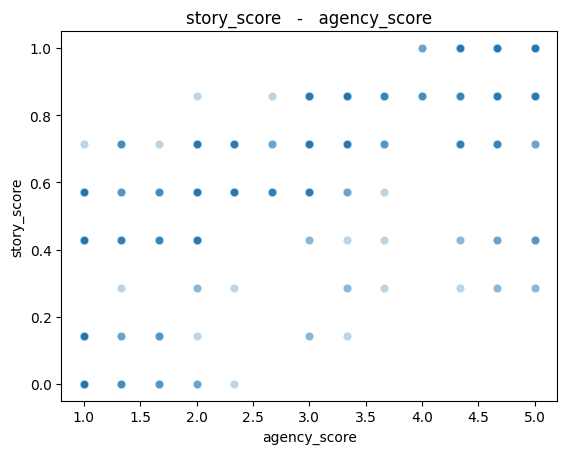

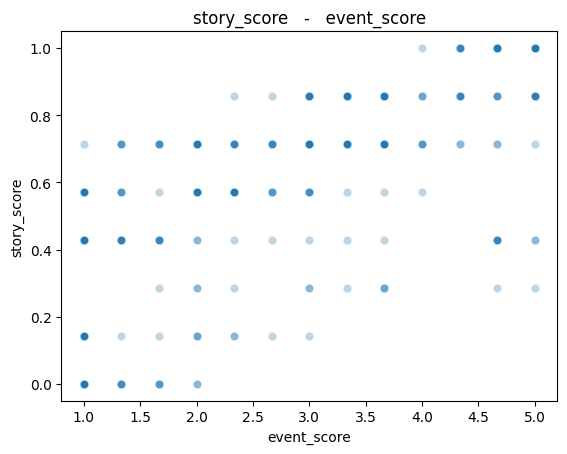

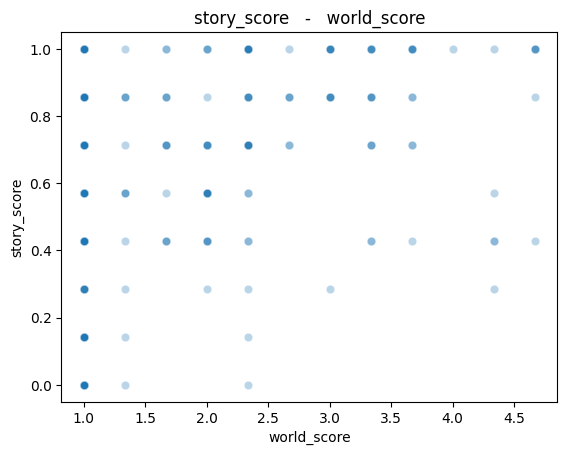

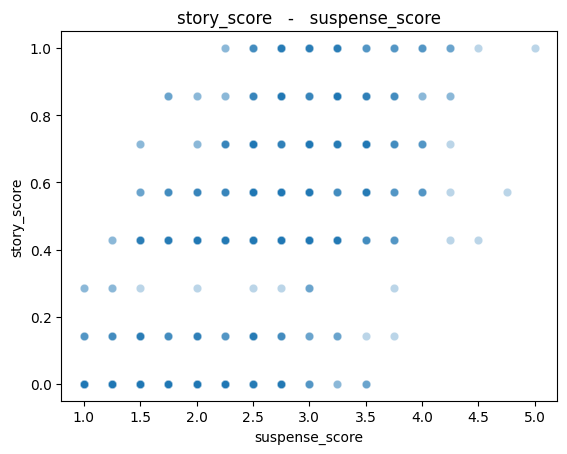

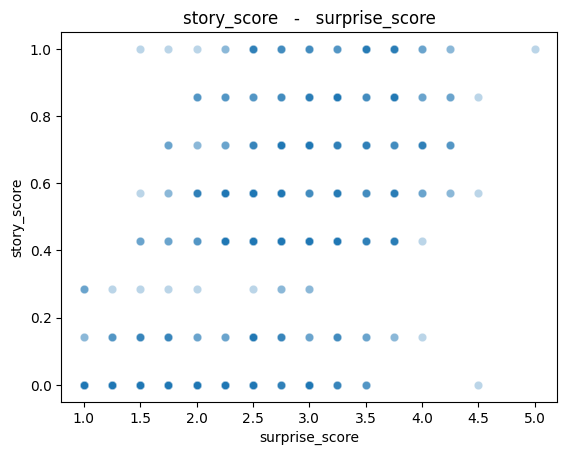

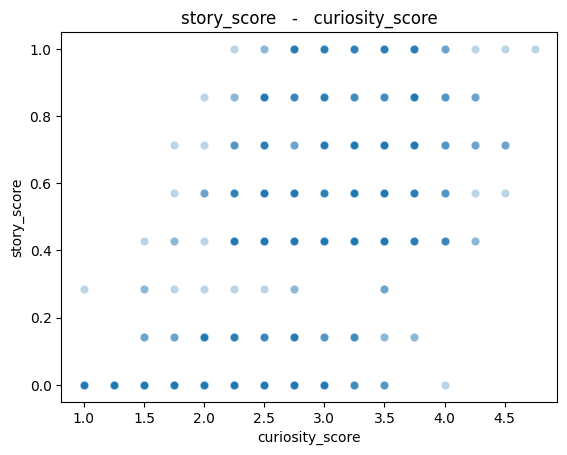

In [3]:
# create a list with all column names of the independent variables
independent_variables = ['agency_score', 'event_score', 'world_score', 'suspense_score', 'surprise_score', 'curiosity_score']

# create scatterplots for each independent variable
for indv in independent_variables:
    sns.scatterplot(data=df, x=indv, y='story_score', alpha=0.3) #alpha makes dots darker if they are overlapping
    plt.title(f"story_score   -   {indv}")
    plt.savefig(f"figures/scatterplot-{indv}.png", dpi=300) # save images for report
    plt.show()

## 2. Linear regression

In [4]:
def linear_regression(dependent_variable, independent_variable): # dependent variable is always story_score
    """
    Takes story_score, performs linear regression based on independent_variable
    outputs
    """
    X = pd.DataFrame(independent_variable) # 2d array is expected by test_train_split 
    y = dependent_variable # story_score
    
    # divide data into train (80%) and test (20%) chunks, random_state=1 makes the results reproducible
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25) 

    # load and fit the regression line
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test) 
    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = r2_score(y_test, y_pred)
    residual = y_test - y_pred
    
    residuals[independent_variable.name] = residual #save the residuals to dict for plotting later
    
    return {
        'variable': independent_variable.name,
        'r2': r2,
        'slope': slope,
        'intercept': intercept
    }

In [5]:
results = []
residuals = {}

for indv in independent_variables:
    results.append(linear_regression(df['story_score'], df[indv]))

results = pd.DataFrame(results)
results

,variable,r2,slope,intercept
0,agency_score,0.611991,0.182044,0.034894
1,event_score,0.631298,0.192458,0.025591
2,world_score,0.217541,0.192434,0.163757
3,suspense_score,0.427826,0.260293,-0.214275
4,surprise_score,0.344165,0.238317,-0.193760
5,curiosity_score,0.337986,0.271064,-0.323235


In [6]:
residuals = pd.DataFrame(residuals)
residuals # note that these are the residuals of the test set only (124 rows)

,agency_score,event_score,world_score,suspense_score,surprise_score,curiosity_score
601,-0.216938,-0.218049,-0.356192,-0.501532,-0.640348,-0.354425
531,-0.074081,-0.075192,-0.213334,-0.293601,-0.020858,-0.414866
400,0.211633,0.210523,0.072380,-0.268181,-0.271356,-0.196917
523,-0.216938,-0.218049,-0.356192,-0.111092,-0.163715,-0.083361
125,0.211633,0.210523,0.072380,-0.072960,-0.152198,-0.196917
...,...,...,...,...,...,...
297,0.090270,0.082218,0.072380,-0.528474,-0.271356,-0.400215
27,0.072578,-0.081136,0.229805,0.342901,0.252675,0.224329
117,0.254622,-0.016983,0.101515,0.017534,0.193096,0.021031
144,0.211633,0.210523,0.072380,0.057186,-0.092619,-0.196917


## 3. Plotting the regression lines on the scatterplots

We could use sns.regplot to make the scatterplot with the regression line, but that does not use the intercept/slope from our 'own' regression model, so we use use sns.axline in combination with sns.scatterplot

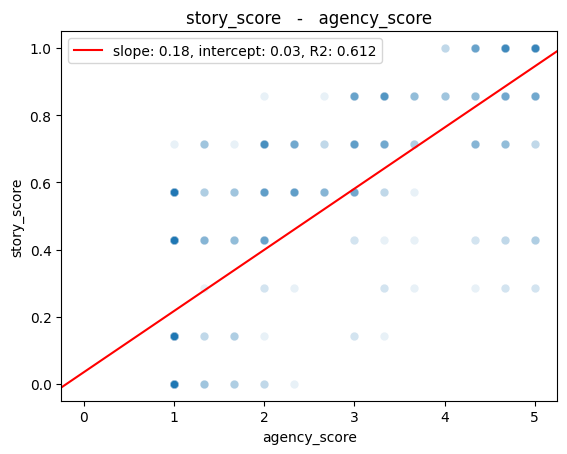

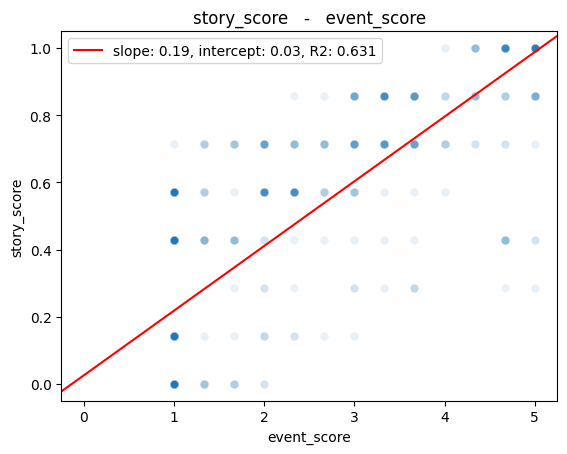

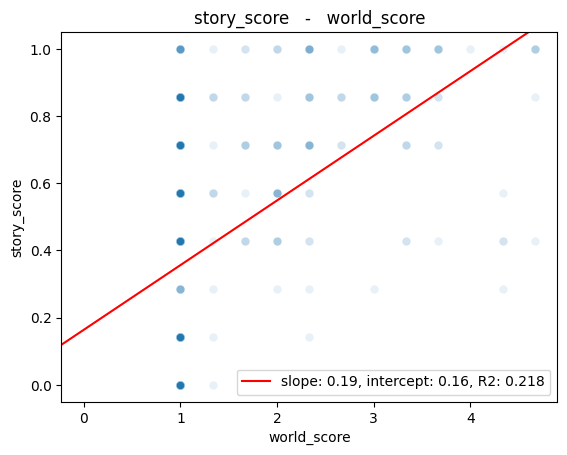

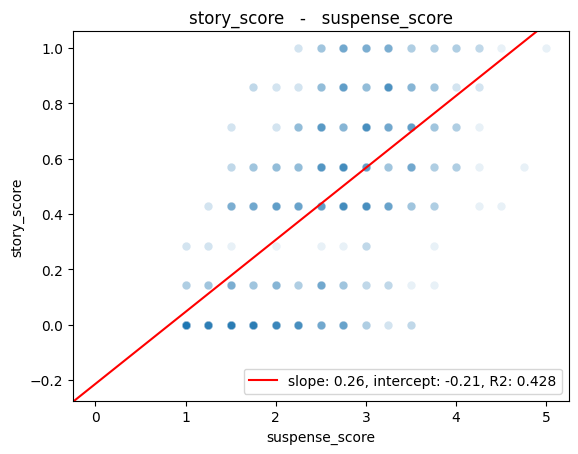

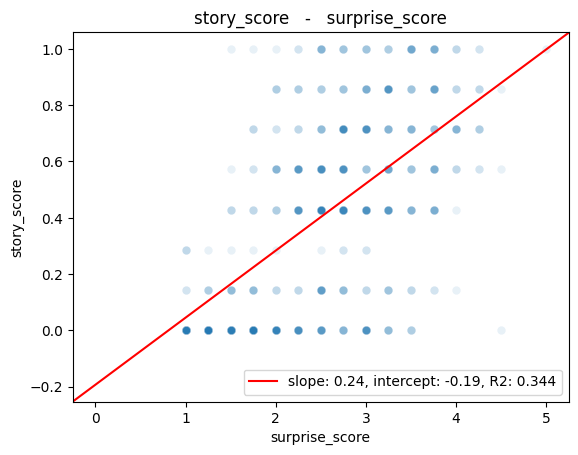

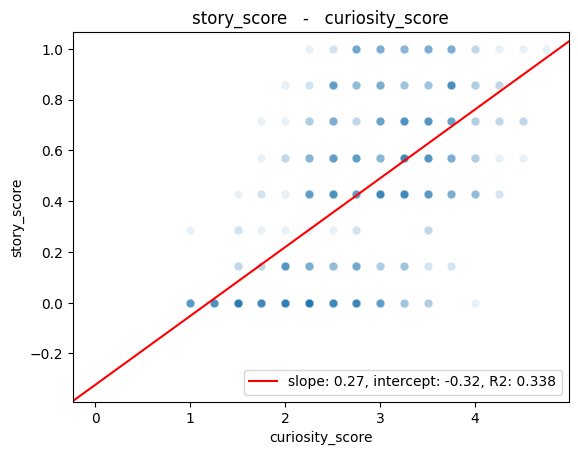

In [7]:
for row in results.itertuples():
    
    # scatterplot
    sns.scatterplot(data=df, x=row.variable, y='story_score', alpha=0.1) #alpha makes dots darker if they are duplicate

    # plot regression line
    x_range = np.array([1, 5])
    y_range = row.slope * x_range + row.intercept
    plt.axline((0, row.intercept), slope=row.slope, color='red', label=f"slope: {row.slope:.2f}, intercept: {row.intercept:.2f}, R2: {row.r2:.3f}")
    plt.title(f"story_score   -   {row.variable}")
    plt.legend()
    plt.savefig(f"figures/regline-{row.variable}.png", dpi=300) # save images for report
    plt.show()

# 4. Checking for normality in the residuals

Shapiro-Wilk Test for agency_score
P-value: 0.00000081790149949094
W: 0.9144345421906948


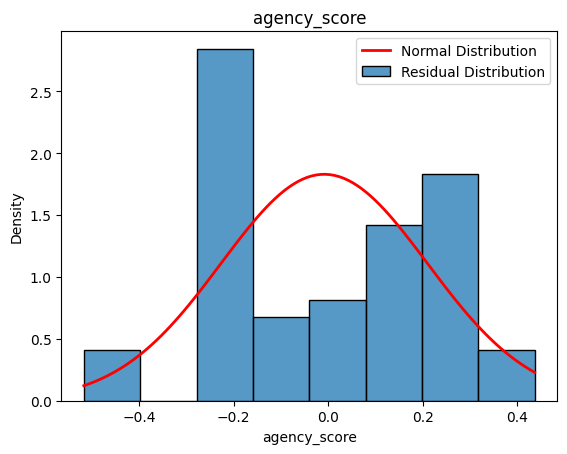

Shapiro-Wilk Test for event_score
P-value: 0.00000045118394050296
W: 0.9098183083027874


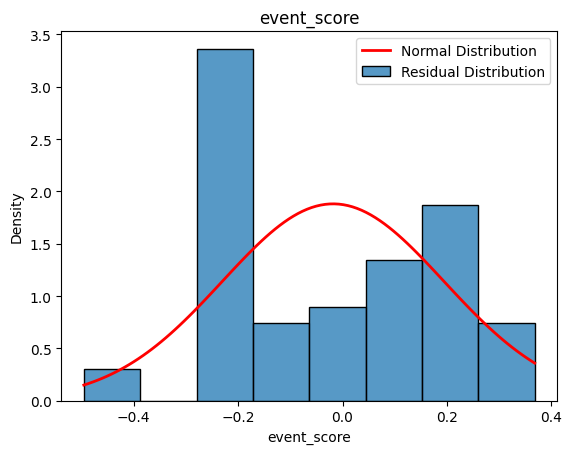

Shapiro-Wilk Test for world_score
P-value: 0.00000006228805202337
W: 0.8934260211033124


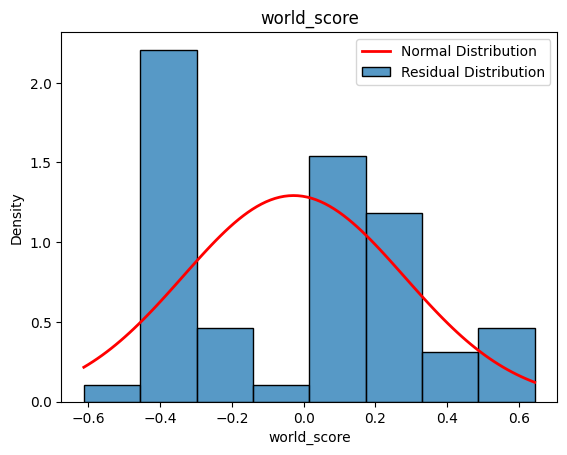

Shapiro-Wilk Test for suspense_score
P-value: 0.60216832857573354687
W: 0.9909937960503414


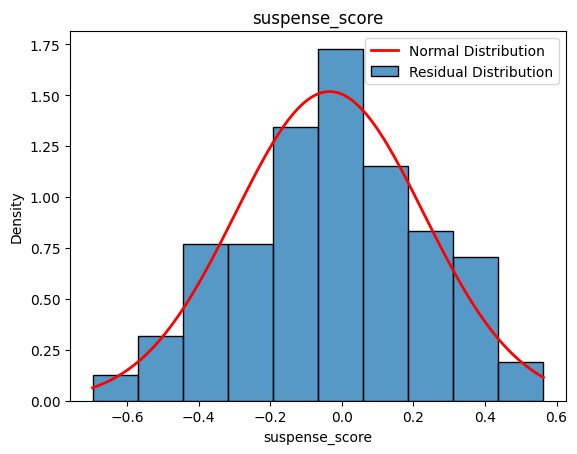

Shapiro-Wilk Test for surprise_score
P-value: 0.08808790605444112576
W: 0.9815331190505762


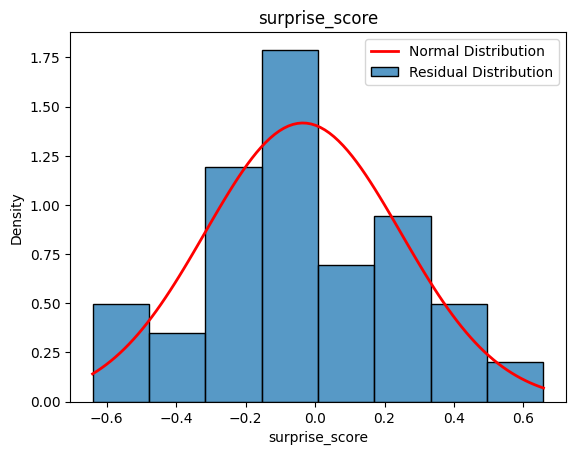

Shapiro-Wilk Test for curiosity_score
P-value: 0.52663858552468889584
W: 0.990188798941325


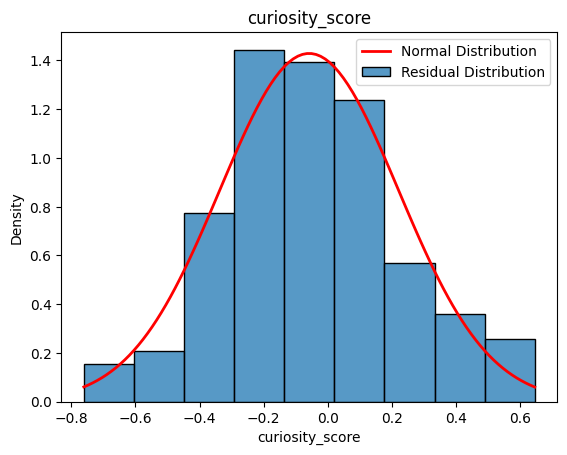

In [8]:
for name, residual in residuals.items():
    shapiro_test = stats.shapiro(residual)

    #plot residual histogram
    sns.histplot(data=residual, stat='density', label=f"Residual Distribution") #stat is set to density to normalize raw word counts with the normal dist line
    plt.title(name)
    
    #plot normal dist line
    mu, std = stats.norm.fit(residual)
    x = np.linspace(min(residual), max(residual), 100)
    plt.plot(x, stats.norm.pdf(x, mu, std), color='red', linewidth=2, label="Normal Distribution")
    
    plt.legend()
    print(f"Shapiro-Wilk Test for {name}\nP-value: {shapiro_test.pvalue:.20f}\nW: {shapiro_test.statistic}")
    plt.savefig(f"figures/residuals-hist-{name}.png", dpi=300) # save images for report
    plt.show()

Shapiro-Wilk p-value:8.179014994909406e-07


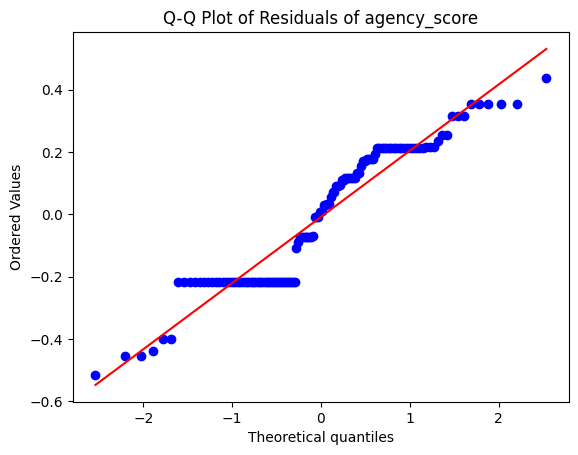

Shapiro-Wilk p-value:4.5118394050296387e-07


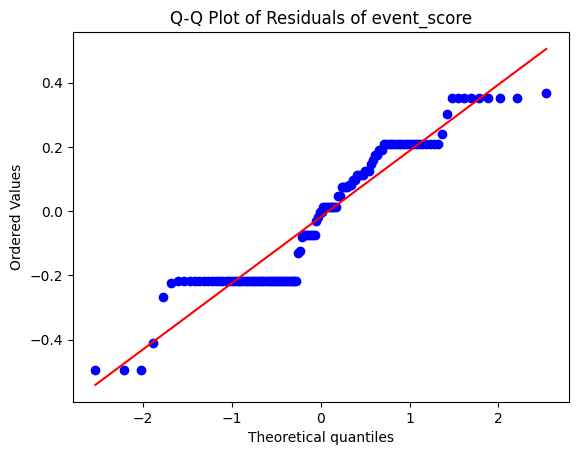

Shapiro-Wilk p-value:6.228805202337498e-08


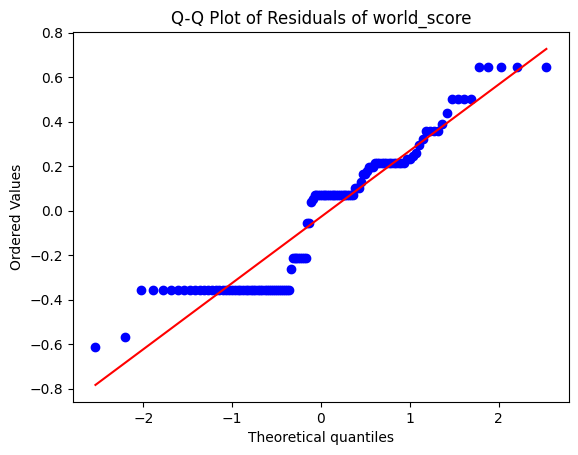

Shapiro-Wilk p-value:0.6021683285757335


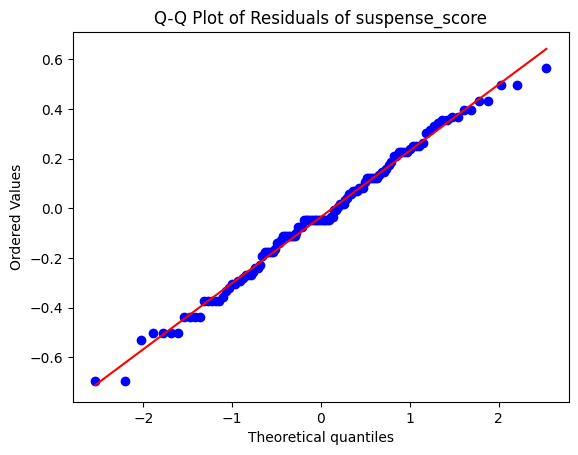

Shapiro-Wilk p-value:0.08808790605444113


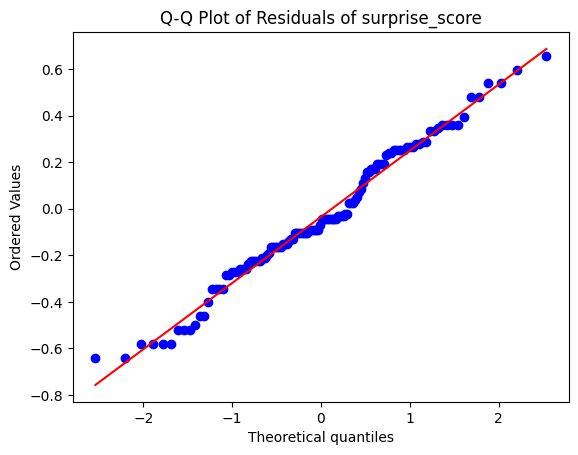

Shapiro-Wilk p-value:0.5266385855246889


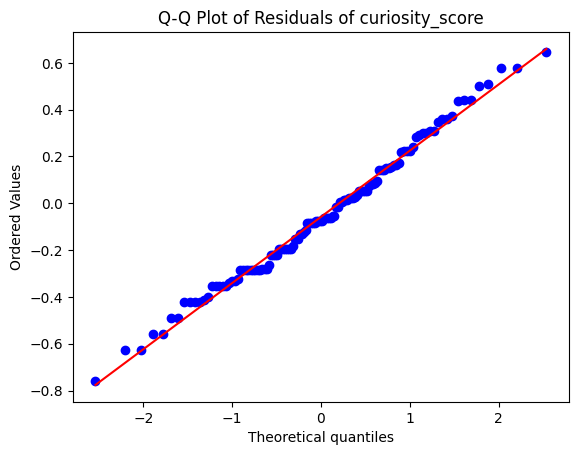

In [9]:
for indv in independent_variables:
    stats.probplot(residuals[indv], dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of Residuals of {indv}")
    print(f"Shapiro-Wilk p-value:{stats.shapiro(residuals[indv]).pvalue}")
    plt.savefig(f"figures/residuals-quantiles-{indv}.png", dpi=300) # save images for report
    plt.show()